### Missing Imputation

In [2]:
import pandas as pd
df=pd.read_csv(r'C:\Users\Venugopal\OneDrive\Desktop\Batch_423\EDA\data\std_multinan.csv')
df

,Name,English,Science
0,AAA,50.0,40.0
1,BBB,NaN,45.0
2,CCC,NaN,58.0
3,DDD,NaN,90.0
4,EEE,NaN,55.0
5,NaN,40.0,NaN
6,GGG,45.0,NaN
7,NaN,58.0,NaN
8,KKK,90.0,90.0


In [3]:
df.fillna(method='bfill')

C:\Users\Venugopal\AppData\Local\Temp\ipykernel_2932\2831856154.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill')


,Name,English,Science
0,AAA,50.0,40.0
1,BBB,40.0,45.0
2,CCC,40.0,58.0
3,DDD,40.0,90.0
4,EEE,40.0,55.0
5,GGG,40.0,90.0
6,GGG,45.0,90.0
7,KKK,58.0,90.0
8,KKK,90.0,90.0


In [4]:
df.fillna(method='ffill')

C:\Users\Venugopal\AppData\Local\Temp\ipykernel_2932\1193302488.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill')


,Name,English,Science
0,AAA,50.0,40.0
1,BBB,50.0,45.0
2,CCC,50.0,58.0
3,DDD,50.0,90.0
4,EEE,50.0,55.0
5,EEE,40.0,55.0
6,GGG,45.0,55.0
7,GGG,58.0,55.0
8,KKK,90.0,90.0


In [5]:
df['Science '].fillna(df['Science '].median())


0    40.0
1    45.0
2    58.0
3    90.0
4    55.0
5    56.5
6    56.5
7    56.5
8    90.0
Name: Science , dtype: float64

In [6]:
df['Science '].median()

56.5

In [7]:
df['Science ']=df['Science '].fillna(df['Science '].median())

In [8]:
df=pd.read_csv(r'C:\Users\Venugopal\OneDrive\Desktop\Batch_423\EDA\data\std_drop_na.csv')
df

,StdID,StdName,Class,Location,Total
0,111.0,A,10.0,NaN,180.0
1,NaN,B,11.0,Viz,NaN
2,113.0,NaN,12.0,Blr,150.0
3,NaN,NaN,NaN,NaN,NaN
4,115.0,E,10.0,Viz,NaN
5,NaN,F,11.0,Blr,140.0
6,117.0,G,NaN,Hyd,188.0
7,NaN,NaN,NaN,NaN,NaN
8,119.0,I,9.0,Blr,NaN


In [9]:
df['Location'].mode()[0]

'Blr'

In [10]:
df['Location'].value_counts()

Location
Blr    3
Viz    2
Hyd    1
Name: count, dtype: int64

In [11]:
df['Location']=df['Location'].fillna(df['Location'].mode()[0])

### Interpolation


**One more way to handle missing values in DataFrame is `interpolate() function`. It replace NaN values with the average  of the previous and next row.**

In [ ]:
dftemp = pd.read_csv(r"data/hyd_outliers.csv")

In [ ]:
dftemp

,Date,Temp
0,21-01-2022,30.0
1,22-01-2022,28.0
2,23-01-2022,NaN
3,24-01-2022,29.0
4,25-01-2022,4450.0
5,26-01-2022,32.0
6,27-01-2022,34.0
7,28-01-2022,-50.0
8,29-01-2022,36.0
9,30-01-2022,38.0


In [ ]:
dftemp.interpolate()

,Date,Temp
0,21-01-2022,30.0
1,22-01-2022,28.0
2,23-01-2022,28.5
3,24-01-2022,29.0
4,25-01-2022,4450.0
5,26-01-2022,32.0
6,27-01-2022,34.0
7,28-01-2022,-50.0
8,29-01-2022,36.0
9,30-01-2022,38.0


In [ ]:
dfage = pd.read_csv(r"data\std_interp.csv")

In [ ]:
dfage

,Stdname,StdClass,Age
0,AAA,10,15.0
1,BBB,11,NaN
2,CCC,12,18.0
3,DDD,10,NaN
4,EEE,11,16.0
5,FFF,12,18.0
6,GGG,11,16.0
7,HHH,10,15.0
8,JJJ,12,NaN
9,KKK,10,NaN


In [ ]:
dfage.interpolate()

,Stdname,StdClass,Age
0,AAA,10,15.0
1,BBB,11,16.5
2,CCC,12,18.0
3,DDD,10,17.0
4,EEE,11,16.0
5,FFF,12,18.0
6,GGG,11,16.0
7,HHH,10,15.0
8,JJJ,12,15.0
9,KKK,10,15.0


# Outlier

- Outliers are values in the data set that are very large or small compared to the majority of the values in the data set. For example, 767 is an outlier in the following data set (130,160,110,49,95,93,120,179,767).

- The machine learning model performance depends on how clean your data is. Even the best machine learning algorithm will not perform well if outliers are present in the data. Outliers affect the training process of a machine learning model, and results can be inaccurate.

In [2]:
import pandas as pd

import numpy as np

In [13]:
df=pd.read_csv(r'C:\Users\Venugopal\OneDrive\Desktop\Batch_423\EDA\data\sales_data_with_outliers.csv')
df

,Transaction_ID,Sales_Amount,Customer_Age,Items_Purchased
0,1,524.835708,27.682425,2.553485
1,2,493.086785,36.480601,3.856399
2,3,532.384427,36.305276,3.214094
3,4,576.151493,35.025567,1.754261
4,5,488.292331,33.827064,3.173181
...,...,...,...,...
95,96,1200.000000,80.000000,10.000000
96,97,1300.000000,85.000000,12.000000
97,98,5.000000,18.000000,0.000000
98,99,10.000000,17.000000,1.000000


In [14]:
df[df['Sales_Amount']==df['Sales_Amount'].max()]

,Transaction_ID,Sales_Amount,Customer_Age,Items_Purchased
99,100,1500.0,90.0,15.0


## Detecting the Outliers

**Detecting outliers with Visualization**


- The easiest way to see the outliers is by using a box plot. A box has two main components a `box` and two `whiskers`. The whiskers represent the data outside the middle 50% of the data. Data values that lie outside the whiskers are considered outliers.

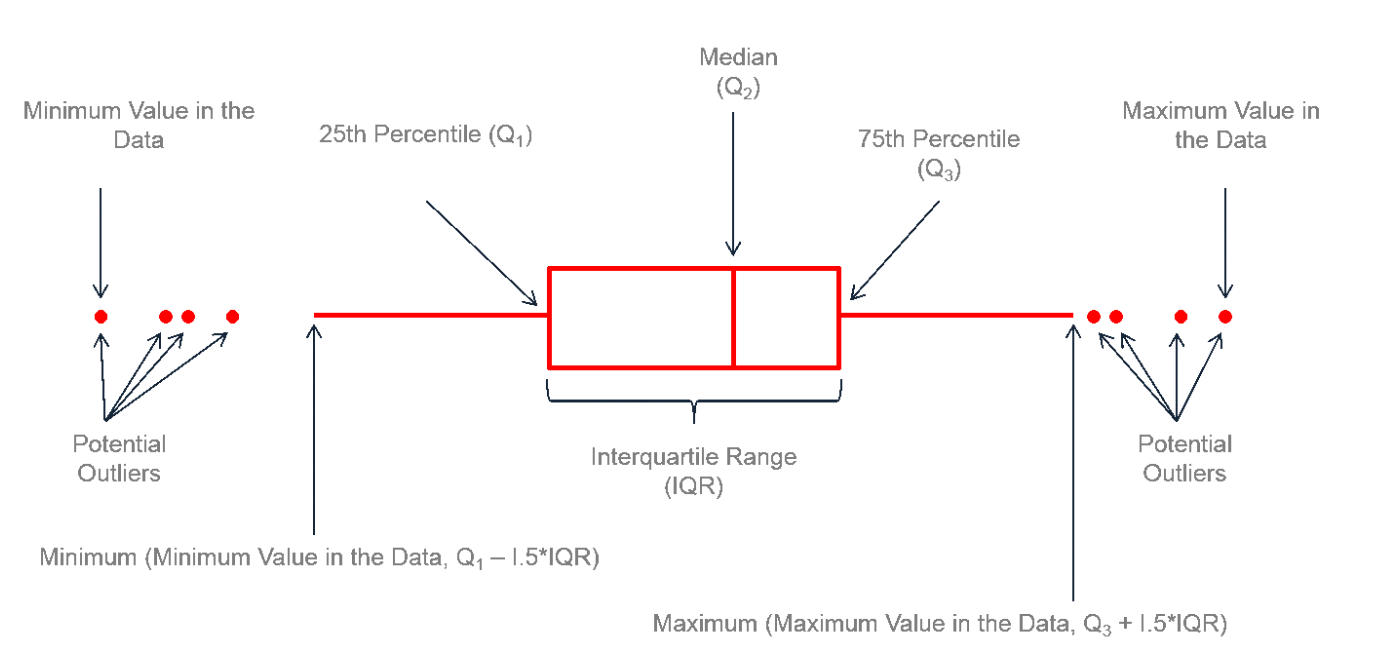

<AxesSubplot:>

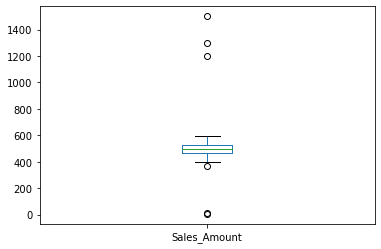

In [11]:
df['Sales_Amount'].plot(kind="box")

- The marks above 83 opprox in the marks column are outliers

**Detecting outliers with Interquartile Range (IQR)**


- In statistics, the interquartile range is a measure of statistical dispersion, which describes the variability in data. To find an IQR, we calculate Q1 and Q3 values then find the IQR by subtracting Q3 from Q1. Q3 is the 75th percentile, and Q1 is the 25th percentile.

- To find Q3 and Q1, we use Pandas quantile method and pass 0.75 and 0.25 values which are 75th and 25th percentile.

In [15]:
df["Sales_Amount"].min()

5.0

In [16]:
Q1=df["Sales_Amount"].quantile(0.25)
Q1

np.float64(469.3720051088336)

In [20]:
df["Sales_Amount"].median()

493.6521854110144

In [21]:
Q3=df["Sales_Amount"].quantile(0.75)
Q3

np.float64(527.9919552449845)

In [22]:
df["Sales_Amount"].max()

1500.0

**Calculating IQR**

In [23]:
IQR=Q3-Q1
IQR

np.float64(58.61995013615092)

In [24]:
IQR*1.5

np.float64(87.92992520422638)

- Now we will use IQR Method.

**upper Outlier = Q1+(1.5 x IQR)**

**lower Outlier =Q3-(1.5 x IQR)**

- A resulting value from these formulas that is greater than a higher outlier, and less than a lower outlier is considered as an outlier.

In [27]:
Higher_outlier = Q1 +(IQR*1.5)
print(Higher_outlier)

557.30193031306


In [26]:
lower_outlier = Q3 - (IQR*1.5)
print(lower_outlier)

440.06203004075815


- We got 557.5 and 440 values. Let’s check how many outliers are in the marks column.

In [28]:
df[(df["Sales_Amount"] <= lower_outlier) | (df["Sales_Amount"] >= Higher_outlier)]

,Transaction_ID,Sales_Amount,Customer_Age,Items_Purchased
3,4,576.151493,35.025567,1.754261
6,7,578.960641,32.896773,2.116143
13,14,404.335988,36.287752,4.053802
14,15,413.754108,34.627770,1.622331
19,20,429.384815,34.038195,6.852731
20,21,573.282438,36.507737,3.570891
23,24,428.762591,40.714114,3.651391
31,32,592.613909,30.047318,1.132735
35,36,438.957818,27.246683,4.088951
37,38,402.016494,29.688481,1.922255


In [33]:
df.shape

(100, 4)

In [30]:
df[(df['Sales_Amount']>=lower_outlier)&(df['Sales_Amount']<=Higher_outlier)]

,Transaction_ID,Sales_Amount,Customer_Age,Items_Purchased
0,1,524.835708,27.682425,2.553485
1,2,493.086785,36.480601,3.856399
2,3,532.384427,36.305276,3.214094
4,5,488.292331,33.827064,3.173181
5,6,488.293152,27.923146,3.385317
...,...,...,...,...
90,91,504.853877,38.570002,3.113517
91,92,548.432250,37.366188,3.662131
92,93,464.897345,34.635855,4.586017
93,94,483.616893,30.766031,1.762185
